In [57]:

import os
import sys
import time
import torch
import numpy as np
import pandas as pd
import esm
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

sys.path.append("../..")
from balm import common_utils
from balm.models.utils import load_trained_model
from balm.configs import Configs
from balm.models import BALM
from balm.metrics import get_ci, get_pearson, get_rmse, get_spearman



In [58]:
if torch.cuda.is_available():
    DEVICE = "cuda" 
else:
     DEVICE = 'cpu'

In [59]:
DEVICE

'cuda'

In [60]:
seed = 42
torch.cuda.manual_seed(seed)

In [61]:
# Define save and load checkpoint functions
def save_checkpoint(model, optimizer, epoch, file_path):
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': epoch
    }
    torch.save(checkpoint, file_path)
    print(f"Checkpoint saved at epoch {epoch} to {file_path}")

def load_checkpoint(model, optimizer,file_path):
    checkpoint = torch.load(file_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    print(f"Checkpoint loaded from {file_path}, resuming from epoch {start_epoch}")
    return start_epoch

# Load Pretrained BindingDB BALM

In [62]:
# Load config and model for zero-shot
config_filepath = "../../default_configs/balm_peft.yaml"
configs = Configs(**common_utils.load_yaml(config_filepath))

# Custom Dummy Data

Alternative to loading the data from a HF repo, you can also bring in your own custom data.

In [63]:
pip install pandas openpyxl

[notice] A new release of pip is available: 24.3.1 -> 25.0

[notice] To update, run: python.exe -m pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: numpy>=1.26.0 in c:\users\hs494\appdata\local\anaconda3\lib\site-packages (from pandas) (1.26.4)



In [65]:
df = pd.read_excel(r"C:\Users\hs494\Downloads\BALM\scripts\notebooks\PPBAffinity_with_sequences.xlsx")
df


,proteina,Target,Y,Unnamed: 0,Source Data Set,Complex ID,PDB,Mutations,Ligand Chains,Receptor Chains,...,KD(M),Affinity Method,Structure Method,Temperature(K),Resolution(Å),PDB PubMed ID,PDB Release Date,Affinity PubMed ID,Affinity Release Date,Subgroup
0,SQVQLQESGGGLVQAGGSLRLSCAASGSIFALNIMGWYRQAPGKQR...,AAAKVMSLLMALVVLLIVAGNVLVIAAIGSTQRLQTLTNLFITSLA...,9.853872,7149,SAbDab,"6H7O:B, D::PMID=TBD",6H7O,NaN,D,B,...,1.400000e-10,Unknown,X-RAY DIFFRACTION,NaN,2.8,31072904.0,2018-10-17,TBD,2018-07-31,Antibody-Antigen
1,SQVQLQESGGGLVQAGGSLRLSCAASGSIFALNIMGWYRQAPGKQR...,AAAKVMSLLMALVVLLIVAGNVLVIAAIGSTQRLQTLTNLFITSLA...,8.455932,7428,SAbDab,"6H7N:B, D::PMID=TBD",6H7N,NaN,D,B,...,3.500000e-09,Unknown,X-RAY DIFFRACTION,NaN,2.5,NaN,2018-10-17,TBD,2018-07-31,Antibody-Antigen
2,SQVQLQESGGGLVQAGGSLRLSCAASGSIFALNIMGWYRQAPGKQR...,AAAKVMSLLMALVVLLIVAGNVLVIAAIGSTQRLQTLTNLFITSLA...,8.455932,7643,SAbDab,"6H7N:A, C::PMID=TBD",6H7N,NaN,C,A,...,3.500000e-09,Unknown,X-RAY DIFFRACTION,NaN,2.5,NaN,2018-10-17,TBD,2018-07-31,Antibody-Antigen
3,SQVQLQESGGGLVQAGGSLRLSCAASGSIFALNIMGWYRQAPGKQR...,AAAKVMSLLMALVVLLIVAGNVLVIAAIGSTQRLQTLTNLFITSLA...,9.853872,7750,SAbDab,"6H7O:A, C::PMID=TBD",6H7O,NaN,C,A,...,1.400000e-10,Unknown,X-RAY DIFFRACTION,NaN,2.8,31072904.0,2018-10-17,TBD,2018-07-31,Antibody-Antigen
4,XESKNKNGDYVIPDSVKNYDGEPLYILVSLWCKLQEKWISRNDIAE...,AAASXIXKDGIYSIIFISNEDSCGEGILIKNGNXITGGDIASVYQG...,5.958607,10808,PDBbind v2020,"4KT5:A, B, C::PMID=24092262",4KT5,NaN,C,"A, B",...,1.100000e-06,NaN,X-RAY DIFFRACTION,NaN,2.7,24092262.0,2013-10-09,24092262,2013,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12014,QVQLQQSGGELVKPGASVKLSCKTSGFTFSSSYISWLKQKPGQSLE...,YVDVGPDSVKSACIEVDIQQTFFDKTWPRPIDVSKADGIIYPQGRT...,7.552842,12107,PDBbind v2020,"6PXH:A, C, D::PMID=31553909",6PXH,NaN,"C, D",A,...,2.800000e-08,NaN,X-RAY DIFFRACTION,NaN,2.3,31553909.0,2019-09-25,31553909,2019 Sep 24,NaN
12015,QVQLQQSGGELVKPGASVKLSCKTSGFTFSSSYISWLKQKPGQSLE...,YVDVGPDSVKSACIEVDIQQTFFDKTWPRPIDVSKADGIIYPQGRT...,7.552842,12108,PDBbind v2020,"6PXH:B, H, L::PMID=31553909",6PXH,NaN,"H, L",B,...,2.800000e-08,NaN,X-RAY DIFFRACTION,NaN,2.3,31553909.0,2019-09-25,31553909,2019 Sep 24,NaN
12016,GSVEKLTADAELQRLKNEAAEEAELERLKSERHDHDKKEAERKALE...,YVEFSEECMHGSGENYDGKISKTMSGLECQAWDSQSPHAHGYIPSK...,8.045757,12143,PDBbind v2020,"6OQJ:A, B::PMID=31301349",6OQJ,NaN,B,A,...,9.000000e-09,NaN,SOLUTION NMR,NaN,NaN,31301349.0,2019-07-24,31301349,2019 Oct 1,NaN
12017,GSVEKLTADAELQRLKNERHEEAELERLKSEAADHDKKEAERKALE...,YVEFSEECMHGSGENYDGKISKTMSGLECQAWDSQSPHAHGYIPSK...,7.376751,12372,PDBbind v2020,"6OQK:A, B::PMID=31301349",6OQK,NaN,B,A,...,4.200000e-08,NaN,SOLUTION NMR,NaN,NaN,31301349.0,2019-07-24,31301349,2019 Oct 1,NaN


In [66]:

# Calculate bounds
data_min = df['Y'].min()
data_max = df['Y'].max()
print(f"Data range: {data_min:.4f} to {data_max:.4f}")

Data range: 1.3188 to 15.6990


### Zero shot predictions with pretrained BindingDB(Deleted its code )


# Few shot training

Note: This is a simplified training process, for a more tested approach, please refer to our `balm/trainer.py`

In [67]:
# Few shot training
from sklearn.model_selection import train_test_split

# Split data
train_data, test_data = train_test_split(df, train_size=0.2, random_state=1234)
print(f"Number of train data: {len(train_data)}")
print(f"Number of test data: {len(test_data)}")

Number of train data: 2403
Number of test data: 9616


In [68]:
# Calculate bounds from the dataset
pkd_lower_bound = df['Y'].min()  # or set it to the value you prefer
pkd_upper_bound = df['Y'].max()  # or set it to the value you prefer

print(f"pkd_lower_bound: {pkd_lower_bound}, pkd_upper_bound: {pkd_upper_bound}")


pkd_lower_bound: 1.3187587626244128, pkd_upper_bound: 15.698970004336019


In [69]:
'''
#commenting this because I am normalizing below directly in traing and testing
# Define a function that applies the cosine similarity conversion to a single example
# This is VERY IMPORTANT since BALM uses cosine similarity
def add_cosine_similarity(example, pkd_upper_bound, pkd_lower_bound):
    example['cosine_similarity'] = (
        
        (example['Y'] - pkd_lower_bound) / (pkd_upper_bound - pkd_lower_bound)* 2 - 1
    )
    return example

# Use map to apply the function across the entire dataset
train_data = train_data.apply(lambda x: add_cosine_similarity(x, pkd_upper_bound, pkd_lower_bound), axis=1)
test_data = test_data.apply(lambda x: add_cosine_similarity(x, pkd_upper_bound, pkd_lower_bound), axis=1)
'''

"\n#commenting this because I am normalizing below directly in traing and testing\n# Define a function that applies the cosine similarity conversion to a single example\n# This is VERY IMPORTANT since BALM uses cosine similarity\ndef add_cosine_similarity(example, pkd_upper_bound, pkd_lower_bound):\n    example['cosine_similarity'] = (\n        \n        (example['Y'] - pkd_lower_bound) / (pkd_upper_bound - pkd_lower_bound)* 2 - 1\n    )\n    return example\n\n# Use map to apply the function across the entire dataset\ntrain_data = train_data.apply(lambda x: add_cosine_similarity(x, pkd_upper_bound, pkd_lower_bound), axis=1)\ntest_data = test_data.apply(lambda x: add_cosine_similarity(x, pkd_upper_bound, pkd_lower_bound), axis=1)\n"

In [70]:
# Initialize model for training
model = BALM(configs.model_configs)
model = model.to(DEVICE)

In [71]:
import wandb
from torch.optim import AdamW
from tqdm import tqdm
import time


wandb.login(key='60f195a60e62087702e68096c0e54f04406555dc')
# Initialize wandb
wandb.init(project='ppicurated_local_270125', entity='hs494-shiv-nadar-university')

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


CI,▁
Pearson,▁
RMSE,▁
Spearman,▁
epoch,▁▂▃▃▄▅▆▆▇█
loss,█▅▄▃▃▂▂▁▁▁
predicted_pKd,▅▂▁▄▄▅▅▃▄▃▂█▁▄▁▁▁▄▁▁▂▃▂▂▄▃▄▄▄▄▃▅▂▅▄▃▃▂▆▄
total_time,▁
true_pKd,▄▃▅▅█▃▆▆▆▅▃▃▄▅▅▆▅▄▅▅▃▃▇▁▂▅▃▅▃▅▃▅▇▅▄▂▄▃▄▃
CI,0.76308
Pearson,0.71023


In [72]:

# Training loop
NUM_EPOCHS = 40
optimizer = torch.optim.AdamW(
    params=[param for name, param in model.named_parameters()],
    lr=configs.model_configs.model_hyperparameters.learning_rate,
)

print(f"Starting training with learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Training on device: {DEVICE}")
print(f"Total training samples: {len(train_data)}")

Starting training with learning rate: 0.001
Training on device: cuda
Total training samples: 2403


In [73]:

#with normalization
# Log hyperparameters
wandb.config.learning_rate = configs.model_configs.model_hyperparameters.learning_rate
wandb.config.num_epochs = NUM_EPOCHS

# Load checkpoint if exists
checkpoint_path = r"C:\Users\hs494\Downloads\BALM\scripts\notebooks\latest_checkpointcuratedmain.pth"
start_epoch = 0
if os.path.exists(checkpoint_path):
    start_epoch = load_checkpoint(model,optimizer,checkpoint_path)
    

C:\Users\hs494\AppData\Local\Temp\ipykernel_10452\1598579009.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(file_path)


Checkpoint loaded from C:\Users\hs494\Downloads\BALM\scripts\notebooks\latest_checkpointcuratedmain.pth, resuming from epoch 10


In [74]:

#with normalization
# Adjust NUM_EPOCHS to include the epochs already completed
NUM_EPOCHS += start_epoch

start = time.time()
best_loss = float('inf')

for epoch in range(start_epoch,NUM_EPOCHS):
    model.train()
    total_loss = 0.0
    
    # Create progress bar for each epoch
    pbar = tqdm(train_data.iterrows(), total=len(train_data), 
                desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)
    
    batch_losses = []  # Track individual batch losses
    
    for idx, sample in pbar:
        # Scale to cosine similarity range
        cosine_target = 2 * (sample['Y'] - data_min) / (data_max - data_min) - 1
        
        inputs = {
            "protein_sequences": [sample["Target"]],
            "proteina_sequences": [sample["proteina"]],
            "labels": torch.tensor([cosine_target], dtype=torch.float32).to(DEVICE)
        }

        # Print sequence lengths occasionally
        if idx % 100 == 0:
            print(f"\nSequence lengths - Target: {len(sample['Target'])}, "
                  f"ProteinA: {len(sample['proteina'])}")

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = outputs["loss"]
        loss.backward()
        
        # Gradient norm debugging
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        if idx % 100 == 0:
            print(f"Gradient norm: {grad_norm:.4f}")

        optimizer.step()
        
        current_loss = loss.item()
        batch_losses.append(current_loss)
        total_loss += current_loss
        
        # Update progress bar with current loss
        pbar.set_postfix({
            'batch_loss': f'{current_loss:.4f}',
            'avg_loss': f'{total_loss/(idx+1):.4f}'
        })

    avg_loss = total_loss / len(train_data)
    
    # Print detailed epoch summary
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}] Summary:")
    print(f"Average Loss: {avg_loss:.4f}")
    print(f"Min Batch Loss: {min(batch_losses):.4f}")
    print(f"Max Batch Loss: {max(batch_losses):.4f}")
    
    # Track best model
    if avg_loss < best_loss:
        best_loss = avg_loss
        print(f"New best loss achieved! Previous best: {best_loss:.4f}")

    # Print memory usage if using CUDA
    if torch.cuda.is_available():
        print(f"GPU Memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
        print(f"GPU Memory cached: {torch.cuda.memory_reserved()/1e9:.2f} GB")
    
    # Log metrics to wandb
    wandb.log({'epoch': epoch + 1, 'loss': avg_loss})
    
    # Save checkpoint after each epoch
    save_checkpoint(model, optimizer, epoch+1, checkpoint_path)

training_time = time.time() - start
print("\nTraining complete!")
print(f"Total training time: {training_time/60:.2f} minutes")
print(f"Average time per epoch: {training_time/NUM_EPOCHS/60:.2f} minutes")
print(f"Best loss achieved: {best_loss:.4f}")


Epoch 11/50:   1%|▏         | 36/2403 [00:07<06:59,  5.65it/s, batch_loss=0.0161, avg_loss=0.0001]


Sequence lengths - Target: 134, ProteinA: 86
Gradient norm: 0.4975


Epoch 11/50:  12%|█▏        | 297/2403 [01:07<05:59,  5.86it/s, batch_loss=0.0022, avg_loss=0.0030]


Sequence lengths - Target: 283, ProteinA: 135
Gradient norm: 0.0225


Epoch 11/50:  25%|██▍       | 597/2403 [02:06<05:10,  5.81it/s, batch_loss=0.0166, avg_loss=0.0103]

...

Epoch 50/50:  97%|█████████▋| 2340/2403 [14:03<00:21,  2.94it/s, batch_loss=0.0007, avg_loss=0.0049]


Sequence lengths - Target: 211, ProteinA: 191
Gradient norm: 0.0283


Epoch 50/50:  99%|█████████▉| 2381/2403 [14:28<00:14,  1.47it/s, batch_loss=0.0134, avg_loss=0.0056] 


Sequence lengths - Target: 353, ProteinA: 442
Gradient norm: 0.0504



Epoch [50/50] Summary:
Average Loss: 0.0215
Min Batch Loss: 0.0000
Max Batch Loss: 0.5714
GPU Memory allocated: 10.66 GB
GPU Memory cached: 18.57 GB
Checkpoint saved at epoch 50 to C:\Users\hs494\Downloads\BALM\scripts\notebooks\latest_checkpointcuratedmain.pth

Training complete!
Total training time: 594.68 minutes
Average time per epoch: 11.89 minutes
Best loss achieved: 0.0211


## Test the model!

In [75]:

#with normalization
model = model.eval()

predictions = []
labels = []
start = time.time()

for _, sample in test_data.iterrows():
    # Scale target to cosine similarity range (same as training)
    cosine_target = 2 * (sample['Y'] - data_min) / (data_max - data_min) - 1
    
    # Prepare input (exactly matching training format)
    inputs = {
        "protein_sequences": [sample["Target"]],
        "proteina_sequences": [sample["proteina"]],
        "labels": torch.tensor([cosine_target], dtype=torch.float32).to(DEVICE)
    }
    prediction = model(inputs)["cosine_similarity"]
    prediction = model.cosine_similarity_to_pkd(prediction, pkd_upper_bound=pkd_upper_bound, pkd_lower_bound=pkd_lower_bound)
    label = torch.tensor([sample["Y"]])
    
    # Log prediction and true label to W&B
    wandb.log({"predicted_pKd": prediction.item(), "true_pKd": label.item()})

    print(f"Predicted pKd: {prediction.item()} | True pKd: {label.item()}")
    
    predictions.append(prediction.item())
    labels.append(label.item())
# Log the total time taken
wandb.log({"total_time": time.time() - start})

print(f"Time taken for {len(test_data)} protein-proteina pairs: {time.time() - start}")


Predicted pKd: 5.250461578369141 | True pKd: 3.1972947120666504
Predicted pKd: 9.508160591125488 | True pKd: 10.623422622680664
Predicted pKd: 7.938556671142578 | True pKd: 6.752763271331787
Predicted pKd: 8.822324752807617 | True pKd: 11.254924774169922
Predicted pKd: 8.870076179504395 | True pKd: 8.844663619995117
Predicted pKd: 6.803032875061035 | True pKd: 7.7695512771606445
Predicted pKd: 6.269532203674316 | True pKd: 7.022276401519775
Predicted pKd: 6.884914398193359 | True pKd: 9.619789123535156
Predicted pKd: 8.822324752807617 | True pKd: 10.954676628112793
Predicted pKd: 7.556406021118164 | True pKd: 6.379863739013672
Predicted pKd: 8.870076179504395 | True pKd: 9.522878646850586
Predicted pKd: 8.822324752807617 | True pKd: 10.987162590026855
Predicted pKd: 8.870076179504395 | True pKd: 9.0
Predicted pKd: 4.705395698547363 | True pKd: 4.744727611541748
Predicted pKd: 4.782696723937988 | True pKd: 4.494850158691406
Predicted pKd: 10.293322563171387 | True pKd: 10.31336402893066

RMSE: 1.4891573190689087
Pearson: 0.7362605333328247
Spearman: 0.7352470187862362
CI: 0.7730953097343445


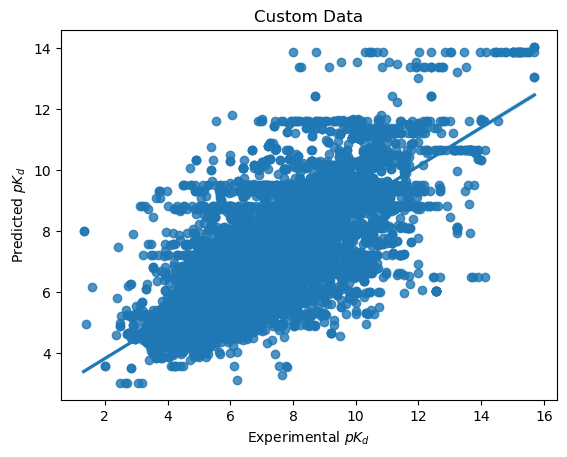

In [76]:
import seaborn as sns
from balm.metrics import get_ci, get_pearson, get_rmse, get_spearman

rmse = get_rmse(torch.tensor(labels), torch.tensor(predictions))
pearson = get_pearson(torch.tensor(labels), torch.tensor(predictions))
spearman = get_spearman(torch.tensor(labels), torch.tensor(predictions))
ci = get_ci(torch.tensor(labels), torch.tensor(predictions))

print(f"RMSE: {rmse}")
print(f"Pearson: {pearson}")
print(f"Spearman: {spearman}")
print(f"CI: {ci}")

# Log metrics to W&B
wandb.log({
    "RMSE": rmse.item(),
    "Pearson": pearson.item(),
    "Spearman": spearman.item(),
    "CI": ci.item()
})

ax = sns.regplot(x=labels, y=predictions)
ax.set_title(f"Custom Data")
ax.set_xlabel(r"Experimental $pK_d$")
ax.set_ylabel(r"Predicted $pK_d$")

# Save the plot
plt.savefig("regression_plot.png")

# Log the plot to W&B
wandb.log({"regression_plot": wandb.Image("regression_plot.png")})

# Optionally show the plot
plt.show()